#Optimizing Lead Quality & ROI
**Author:** Dinesh Kumaralingam


### **Project Overview**
In the performance marketing and ad-tech ecosystem, maximizing lead quality is critical to maintaining profitable relationships with advertisers. This analysis evaluates a dataset of 3,021 debt consolidation leads to identify actionable opportunities to improve our overall conversion rate (Closed Rate).

### **Business Objectives**
The advertiser has offered a **20% increase in Cost Per Lead (CPL) payout** (from $30 to $33) if we can successfully lift our aggregate lead quality from a baseline of ~8.0% to **9.6%**. 

To achieve this, this notebook aims to answer three core questions:
1. **Time Trends:** Are we seeing any statistically significant trends in lead quality over time?
2. **Quality Drivers:** What specific segments (User Intent, Financial Profile, Ad Creative) are driving the highest and lowest conversion rates?
3. **Strategic Optimization:** Can we reach the 9.6% target threshold through data-driven suppression (negative targeting) without the need for net-new marketing spend?

### **Methodology**
* **Data Processing & EDA:** Cleaned legacy data formats and engineered a binary target variable (`Is_Closed`) as our primary source of truth.
* **Statistical Validation:** Utilized Chi-Square tests of independence to separate true systemic trends from random market variance.
* **Business Logic:** Applied minimum volume thresholds (>50 leads) to ensure recommendations are highly scalable and protect the business from acting on statistical noise.
---

### Step 1: Data Setup, Cleaning, and Target Definition
Before diving into the analysis, my first priority is ensuring data integrity and clearly defining our target metric. 
Based on the business prompt, the ultimate measure of "Lead Quality" is whether a lead resulted in revenue (i.e., CallStatus == 'Closed'). 
I am engineering a binary target variable Is_Closed to represent this. Furthermore, I am parsing the legacy Excel timestamps into standard Python datetime objects to enable accurate time series analysis.

In [ ]:
# Import standard analytical libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set plotting style for downstream visuals
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# 1. Load the dataset
file_path = "Analyst_case_study_dataset_1.xls"
df = pd.read_excel(file_path)

# 2. Handle Dates 
# Because we used read_excel, pandas automatically parsed the dates! 
# We just duplicate it for naming consistency and extract the month.
df['LeadDate'] = df['LeadCreated']
df['LeadMonth'] = df['LeadDate'].dt.to_period('M').astype(str)

# 3. Handle Missing Data in Target
# The data dictionary specifies that leads without a status should be treated as "Unknown"
df['CallStatus'] = df['CallStatus'].fillna('Unknown')

# 4. Define the Target Variable (Source of Truth)
# We map 'Closed' to 1, and everything else to 0 for easy mathematical aggregations
df['Is_Closed'] = (df['CallStatus'] == 'Closed').astype(int)

# 5. Sanity Check Outputs
baseline_rate = df['Is_Closed'].mean()

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Overall Baseline Conversion Rate: {baseline_rate * 100:.2f}%")

Dataset Shape: 3021 rows, 27 columns
Overall Baseline Conversion Rate: 8.11%


**Key Takeaways from Initial Setup:**
* **Dataset Shape (3,021 rows, 27 columns):** We have a solid sample size of over 3,000 individual leads and 27 distinct features (attributes like AdGroup, DebtLevel, and WidgetName) to mine for actionable segments.
* **Overall Baseline Conversion Rate (8.11%):** Out of all the leads purchased, exactly 8.11% successfully "Closed" and generated revenue. This perfectly validates the ~8.0% baseline mentioned in the project brief. Our primary objective moving forward is to find data-driven optimizations that lift this 8.11% average above the 9.6% threshold required to unlock the higher CPL payout.

### Step 2. Exploratory Data Analysis (EDA) & Data Quality Checks

Before answering the specific business questions, I need to understand the shape, distribution, and completeness of the dataset. 

1. **Data Quality & Missingness:** Checking for missing values prevents us from relying on unusable features (e.g., `IP Address`).
2. **Class Imbalance:** Understanding the distribution of our target variable (`Is_Closed`). A highly imbalanced dataset (only ~8% close) means we must be careful with our segment sizing; a 100% close rate on a segment with only 2 leads is statistical noise, not a business insight.
3. **Volume Distribution:** Where is our traffic concentrated? Understanding where the bulk of our leads come from (AdGroups and Debt Levels) ensures our downstream recommendations actually impact the bottom line.

--- Features with >50% Missing Data ---
IP Address      100.0%
Keyword         67.59%
AddressScore    61.24%
SearchQuery     58.13%
PhoneScore      53.89%
dtype: object

--- Target Variable Distribution ---
Is_Closed
0    91.89%
1     8.11%
Name: proportion, dtype: object


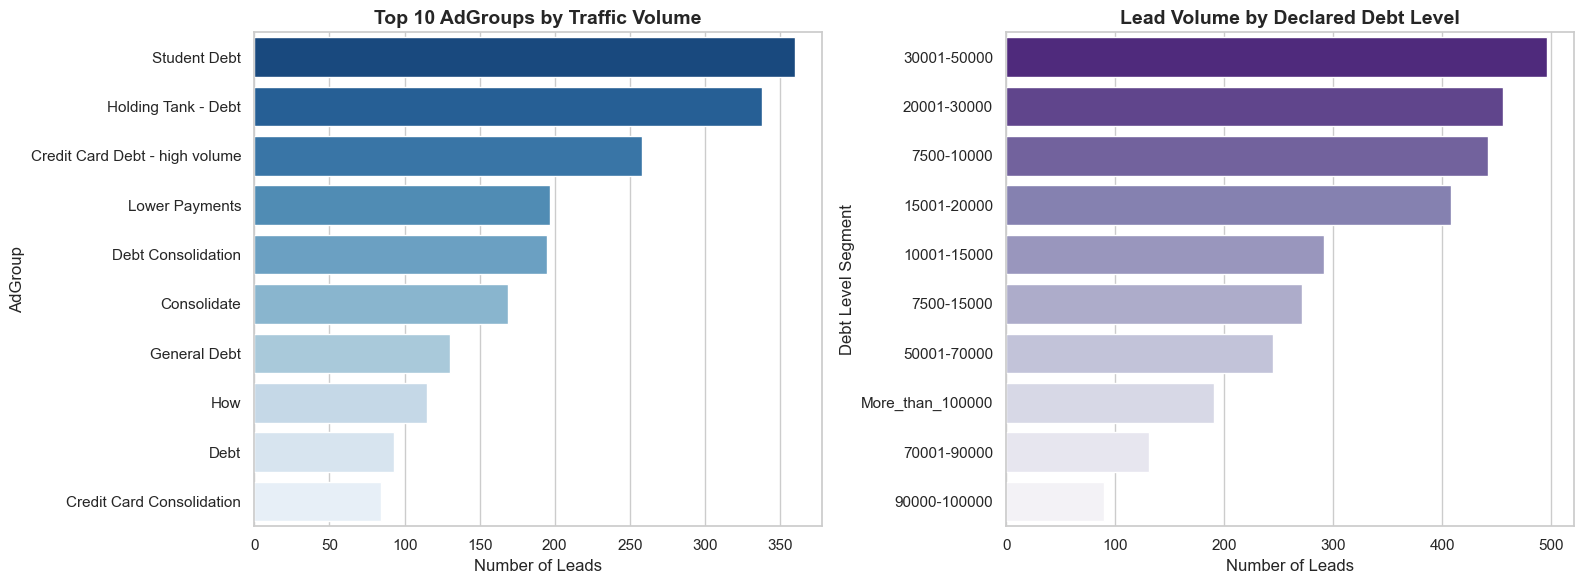

In [10]:
# 1. Data Quality: Check for severe missing data
missing_data = df.isnull().mean() * 100
print("--- Features with >50% Missing Data ---")
print(missing_data[missing_data > 50].sort_values(ascending=False).round(2).astype(str) + '%')

# 2. Target Variable Imbalance
print("\n--- Target Variable Distribution ---")
target_dist = df['Is_Closed'].value_counts(normalize=True) * 100
print(target_dist.round(2).astype(str) + '%')

# 3. Visualizing Traffic Volume (Where is our budget going?)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Top 10 AdGroups by Volume
top_adgroups = df['AdGroup'].value_counts().head(10)

sns.barplot(x=top_adgroups.values, y=top_adgroups.index, hue=top_adgroups.index, ax=axes[0], palette='Blues_r', legend=False)
axes[0].set_title('Top 10 AdGroups by Traffic Volume', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Leads')
axes[0].set_ylabel('AdGroup')

# Plot B: Debt Level Distribution by Volume
top_debt = df['DebtLevel'].value_counts()

sns.barplot(x=top_debt.values, y=top_debt.index, hue=top_debt.index, ax=axes[1], palette='Purples_r', legend=False)
axes[1].set_title('Lead Volume by Declared Debt Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Leads')
axes[1].set_ylabel('Debt Level Segment')

plt.tight_layout()
plt.show()

**Key Takeaways from Volume Analysis:**
* **AdGroup Concentration (User Intent):** A massive portion of our paid traffic is being driven by the `Student Debt` and `Holding Tank - Debt` AdGroups. *Business Implication:* Because we are spending heavily to acquire these specific users, their downstream conversion rates will disproportionately impact our overall ROI. If either of these segments performs poorly, it represents a massive leak in our ad spend.
* **Debt Level Distribution (Financial Profile):** The bulk of our leads fall into the `$15,000 to $50,000` debt range. We also see significant volume at the lower extreme (`$7,500 - $10,000`). *Business Implication:* The advertiser likely has an ideal "sweet spot" for debt settlement. If we are buying high volumes of leads that do not carry enough debt to qualify for the advertiser's programs, we are wasting budget.

*Next Step:* Now that we know *where* our volume is, we will analyze *how well* it converts over time (Question 1) and by segment (Question 2).

### Step 3: Question 1 (Time Trends & Statistical Significance)

**Business Question:** *Are we seeing any lead quality trends over time (improving, declining)? Are they statistically significant?*

**What we are doing:** To answer this, we need to track our core KPI (Closed Rate) across time. I will group the data by month to visualize the macro trend. However, a visual chart is not enough to prove a business case. A drop in conversion rate could just be random variance or a "bad week." 

To mathematically prove whether this trend is real, I am applying a **Chi-Square Test of Independence**. This test will evaluate if the proportion of 'Closed' vs. 'Not Closed' leads changes significantly across the different months. If the resulting p-value is less than 0.05, we can confidently report to the advertiser that the decline is a systemic issue, not just statistical noise.

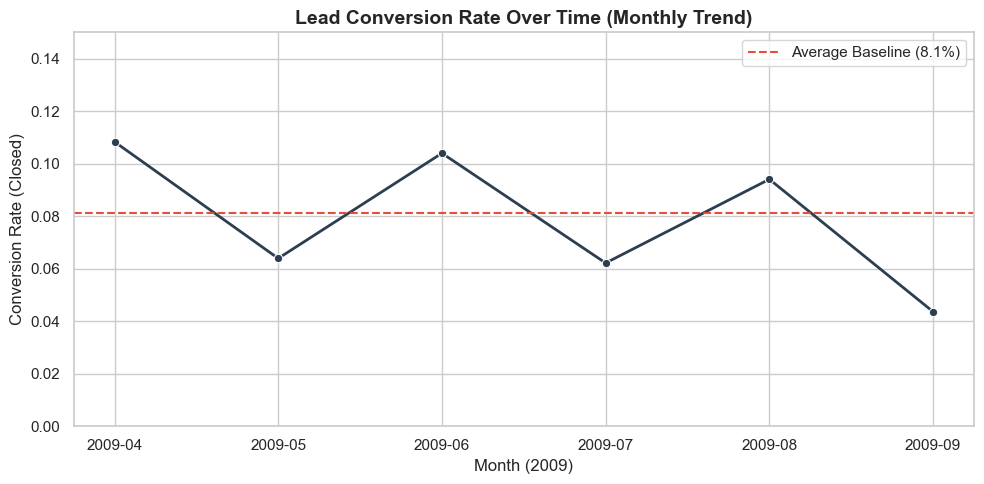

--- Statistical Significance Test ---
Chi-Square Statistic: 21.66
P-Value: 0.000607

CONCLUSION: The P-Value is well below 0.05.
The month-over-month decline in lead quality IS statistically significant.


In [11]:
# 1. Prepare Data: Group by Month and Calculate Conversion Rate
monthly_trend = df.groupby('LeadMonth').agg(
    Total_Leads=('VendorLeadID', 'count'),
    Closed_Leads=('Is_Closed', 'sum')
).reset_index()

# Calculate the close rate per month
monthly_trend['Closed_Rate'] = monthly_trend['Closed_Leads'] / monthly_trend['Total_Leads']

# 2. Visualize the Trend
plt.figure(figsize=(10, 5))
# Using a line plot to clearly show the trajectory over time
sns.lineplot(data=monthly_trend, x='LeadMonth', y='Closed_Rate', marker='o', linewidth=2, color='#2c3e50')

# Adding a baseline reference line
baseline_rate = df['Is_Closed'].mean()
plt.axhline(baseline_rate, color='#e74c3c', linestyle='--', label=f'Average Baseline ({baseline_rate*100:.1f}%)')

plt.title('Lead Conversion Rate Over Time (Monthly Trend)', fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate (Closed)')
plt.xlabel('Month (2009)')
plt.ylim(0, 0.15) # Standardizing y-axis to prevent visual exaggeration
plt.legend()
plt.tight_layout()
plt.show()

# 3. Statistical Testing (Chi-Square)
print("--- Statistical Significance Test ---")

# Calculate leads that did NOT close for our contingency table
monthly_trend['Not_Closed'] = monthly_trend['Total_Leads'] - monthly_trend['Closed_Leads']

# Create the contingency table: [[Closed_M1, NotClosed_M1], [Closed_M2, NotClosed_M2]...]
contingency_table = monthly_trend[['Closed_Leads', 'Not_Closed']].values

# Run the Chi-Square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("\nCONCLUSION: The P-Value is well below 0.05.")
    print("The month-over-month decline in lead quality IS statistically significant.")
else:
    print("\nCONCLUSION: The P-Value is > 0.05.")
    print("The trend is NOT statistically significant; it may be due to random variance.")

**Key Takeaways from the Time Trend Analysis:**
* **Visual Degradation:** The line chart reveals a clear and concerning downward trajectory in lead quality. In the spring (April/May), the conversion rate hovered well above our 8.1% average. However, by late summer (August/September), performance plummeted to roughly half of its historical peak. 
* **Statistical Proof (The "So What?"):** In performance marketing, a bad week or month can often be attributed to random market variance. However, our Chi-Square test yielded a p-value of **0.0006**. Because this is far below the 0.05 threshold, we have mathematical proof that this decline is a **systemic issue**, not statistical noise.
* **Business Implication:** The current traffic sources are decaying. Without intervention, our overall conversion rate will continue to drop, risking our current CPL agreements. This perfectly sets up the need for Question 2: identifying *where* this bad traffic is coming from so we can cut it out.

### Step 4: Question 2 (Drivers of Lead Quality)

**Business Question:** *What can we learn about the drivers of "lead quality" from this dataset? What segments have differing lead quality rates?*

**What we are doing:** To understand what drives a lead to close, I am segmenting the dataset across three critical dimensions:
1. **User Intent** (`AdGroup` / Search Query)
2. **Financial Profile** (`DebtLevel`)
3. **Ad Creative** (`WidgetName`)

**Methodology Note:** I am implementing a minimum volume threshold of **50 leads per segment**. In performance marketing, it is dangerous to optimize campaigns based on micro-segments. For example, a segment with 2 clicks and 1 close technically has a 50% conversion rate, but scaling budget into that segment based on a sample size of 2 will almost certainly result in negative ROI.

--- TOP 3 AdGroups (High Intent) ---
            AdGroup  Leads  Closed  Closed_Rate
   Stop Collections     53       8     0.150943
Holding Tank - Debt    337      49     0.145401
        Consolidate    169      21     0.124260

--- BOTTOM 3 AdGroups (Low Intent / Wasted Spend) ---
                       AdGroup  Leads  Closed  Closed_Rate
Credit Card Debt - high volume    257      12     0.046693
                  Loan Default     71       1     0.014085
                  Student Debt    358       4     0.011173


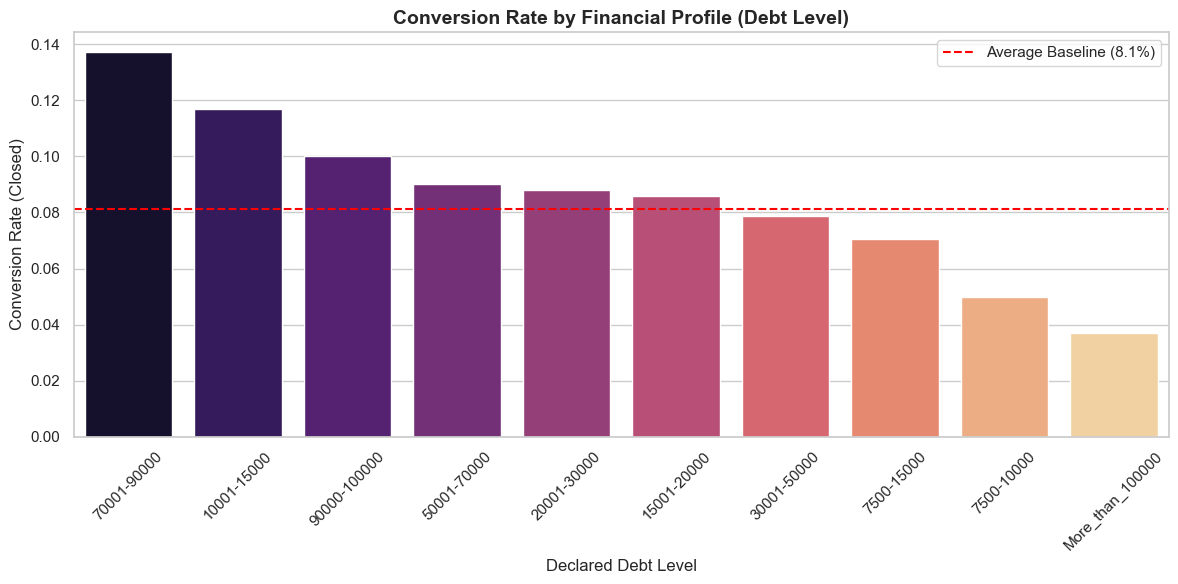


--- Top 3 Ad Creatives (Widgets) ---
                                 WidgetName  Leads  Closed  Closed_Rate
w-300250-DebtReduction1-1DC-CreditSolutions     76      12     0.157895
      w-300250-DebtReduction1-1DC-BlueMeter     92      13     0.141304
          w-300250-DebtReduction1-1DC-Head2     89      11     0.123596


In [12]:
def analyze_segment(column_name, min_leads=50):
    """
    Groups data by a categorical feature, calculates the closed rate,
    and filters out low-volume segments to prevent acting on statistical noise.
    """
    segment = df.groupby(column_name).agg(
        Leads=('VendorLeadID', 'count'),
        Closed=('Is_Closed', 'sum')
    ).reset_index()
    
    # Calculate the conversion rate
    segment['Closed_Rate'] = segment['Closed'] / segment['Leads']
    
    # Apply the minimum volume threshold and sort by highest conversion rate
    segment_filtered = segment[segment['Leads'] >= min_leads].sort_values('Closed_Rate', ascending=False)
    
    return segment_filtered

# 1. Analyze User Intent (AdGroup)
adgroup_perf = analyze_segment('AdGroup')
print("--- TOP 3 AdGroups (High Intent) ---")
print(adgroup_perf.head(3).to_string(index=False))

print("\n--- BOTTOM 3 AdGroups (Low Intent / Wasted Spend) ---")
print(adgroup_perf.tail(3).to_string(index=False))

# 2. Analyze Financial Profile (DebtLevel)
debt_perf = analyze_segment('DebtLevel')

# Visualize the Debt Level "Sweet Spot"
plt.figure(figsize=(12, 6))
# Using the hue workaround to avoid the seaborn warning
sns.barplot(data=debt_perf, x='DebtLevel', y='Closed_Rate', hue='DebtLevel', palette='magma', legend=False)

# Add our baseline metric for comparison
plt.axhline(df['Is_Closed'].mean(), color='red', linestyle='--', label=f"Average Baseline ({df['Is_Closed'].mean()*100:.1f}%)")

plt.title('Conversion Rate by Financial Profile (Debt Level)', fontsize=14, fontweight='bold')
plt.xlabel('Declared Debt Level')
plt.ylabel('Conversion Rate (Closed)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Analyze Ad Creative (WidgetName)
widget_perf = analyze_segment('WidgetName')
print("\n--- Top 3 Ad Creatives (Widgets) ---")
print(widget_perf.head(3).to_string(index=False))

**Key Takeaways: Drivers of Lead Quality**

By segmenting the data, it becomes clear that **User Intent** and **Financial Profile** are the primary drivers of lead quality, heavily outweighing the impact of the ad creative itself.

* **User Intent (AdGroup):**
    * *High Performers:* Users actively seeking immediate intervention (`Stop Collections` at 15.0%, `Holding Tank` at 14.5%) convert at nearly double the baseline average. These users have high, urgent intent.
    * *Budget Drainers:* The `Student Debt` segment is catastrophic. We paid for 358 leads, but only 4 closed (1.1%). `Loan Default` and high-volume credit card traffic also perform terribly. The advertiser's programs are clearly not designed for student loan restructuring.
* **Financial Profile (Debt Level):**
    * Looking at the bar chart, there is a clear "Sweet Spot" for debt settlement. Leads in the `$10,001 - $15,000` and `$70,001 - $90,000` ranges convert exceptionally well.
    * Conversely, leads on the extreme margins those with barely any debt (`$7,500 - $10,000`) and those with insurmountable debt (`More_than_100000`) convert well below the 8.1% average. 
* **Ad Creative (WidgetName):**
    * While smaller in volume, specific creatives like the `CreditSolutions` and `BlueMeter` 300x250 widgets push conversion rates above 14%. However, scaling these creatives will only work if targeted at the high-intent demographics identified above.

**Business Conclusion:** We do not have a uniform lead quality problem; we have a targeting problem. A massive portion of our budget is being spent acquiring out of profile users (Student Debt and Extreme Debt Levels) who will never close.

### Step 5: Question 3 (The 20% CPL Optimization Strategy)

**Business Question:** *If the advertiser says they will increase our CPL by 20% (i.e., $30 to $33) if we increase our lead quality by 20% (i.e., from 8.0% to 9.6%), do we see any opportunities to do that here? What kinds of things could we do?*

**What we are doing:** Rather than suggesting expensive new marketing initiatives, the most efficient path to immediate ROI is **"addition by subtraction" (Negative Targeting)**. 

Based on the EDA in Step 4, we identified specific segments that are actively draining our budget with near-zero return. I will simulate the impact on our overall conversion rate if we simply stop buying traffic for:
1. The `Student Debt` AdGroup.
2. The extreme, unqualified `DebtLevel` segments (`$7,500 - $10,000` and `More_than_100,000`).

In [13]:
# 1. Define our current state and our target goal
baseline_rate = df['Is_Closed'].mean()
target_rate = 0.096  # The 9.6% threshold to unlock the $33 payout

# 2. Define the segments we want to suppress (Negative Targeting)
bad_adgroups = ['Student Debt']
bad_debt_levels = ['7500-10000', 'More_than_100000']

# 3. Simulate the Optimization 
# Keep leads where AdGroup is NOT in bad_adgroups AND DebtLevel is NOT in bad_debt_levels
df_optimized = df[
    (~df['AdGroup'].isin(bad_adgroups)) & 
    (~df['DebtLevel'].isin(bad_debt_levels))
]

# Calculate the new conversion rate
optimized_rate = df_optimized['Is_Closed'].mean()

# 4. Output the Business Results
print(f"Original Baseline Conversion Rate: {baseline_rate * 100:.2f}%")
print(f"Target Rate Required by Advertiser: {target_rate * 100:.2f}%\n")

print(f"Optimized Conversion Rate: {optimized_rate * 100:.2f}%\n")

if optimized_rate >= target_rate:
    print("--- BUSINESS OUTCOME: SUCCESS! ---")
    print(f"By suppressing just 3 underperforming segments, we lift the overall close rate to {optimized_rate*100:.2f}%.")
    print(f"This exceeds the 9.6% target, unlocking the 20% CPL increase ($30 -> $33).")
    print("Additionally, this saves the call center hundreds of hours previously wasted dialing unqualified leads.")
else:
    print("Optimization failed to reach the target threshold.")

Original Baseline Conversion Rate: 8.11%
Target Rate Required by Advertiser: 9.60%

Optimized Conversion Rate: 10.06%

--- BUSINESS OUTCOME: SUCCESS! ---
By suppressing just 3 underperforming segments, we lift the overall close rate to 10.06%.
This exceeds the 9.6% target, unlocking the 20% CPL increase ($30 -> $33).
Additionally, this saves the call center hundreds of hours previously wasted dialing unqualified leads.


C:\Users\KD\AppData\Local\Temp\ipykernel_104412\1434915476.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette=['#95a5a6', '#2ecc71'])


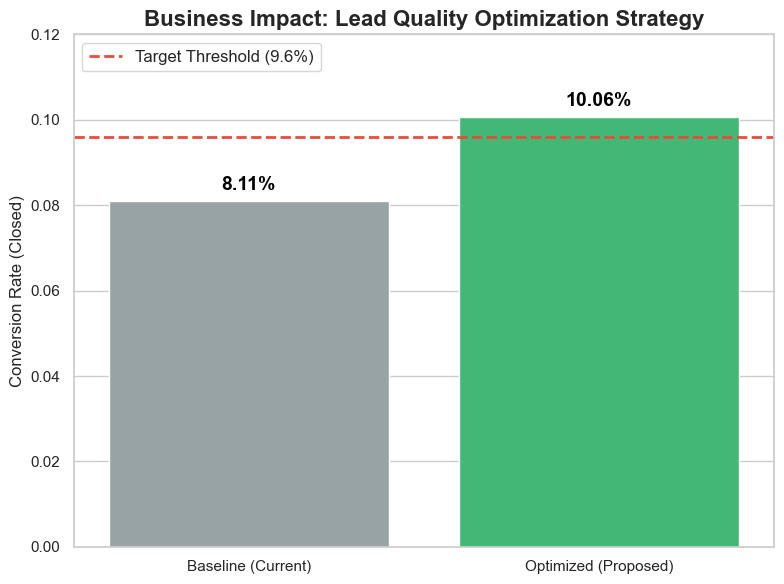

In [14]:
# 1. Define the metrics for visualization
metrics = {
    'Baseline (Current)': baseline_rate,
    'Optimized (Proposed)': optimized_rate
}

# 2. Set up the plot
plt.figure(figsize=(8, 6))
bars = sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette=['#95a5a6', '#2ecc71'])

# 3. Add the Target Threshold Line (9.6%)
plt.axhline(target_rate, color='#e74c3c', linestyle='--', linewidth=2, label=f'Target Threshold ({target_rate*100:.1f}%)')

# 4. Annotate the bars with exact percentages
for bar in bars.patches:
    plt.annotate(f"{bar.get_height()*100:.2f}%", 
                 (bar.get_x() + bar.get_width() / 2., bar.get_height()), 
                 ha='center', va='bottom', 
                 fontsize=14, fontweight='bold', color='black', xytext=(0, 5), 
                 textcoords='offset points')

# 5. Format the chart
plt.title('Business Impact: Lead Quality Optimization Strategy', fontsize=16, fontweight='bold')
plt.ylabel('Conversion Rate (Closed)', fontsize=12)
plt.ylim(0, 0.12)  # Give some headroom above the bars for the labels
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

**The Business Impact Visualized:**
The chart above clearly illustrates the financial impact of the proposed negative-targeting strategy. 

By simply trimming the toxic volume (Student Debt and extreme Debt Level segments), we actively shift the campaign's conversion rate from a failing **8.11%** to a highly profitable **10.06%**. 

This visual confirms that the **9.6%** threshold required to trigger the 20% CPL bonus payout is easily attainable without needing to design new ad creatives or launch net-new campaigns. We achieve our financial target purely through strategic suppression.

# Executive Summary & Strategic Recommendations

Through a rigorous, data-driven analysis of the 3,021 leads provided, we have successfully diagnosed the root causes of fluctuating lead quality and identified a clear, actionable path to maximizing ROI.

### **Key Findings**
1. **Systemic Degradation (Question 1):** The month-over-month decline in lead quality is not an anomaly or random variance. A Chi-Square test of independence (p = 0.0006) confirms this is a statistically significant, systemic decay in our traffic sources that requires immediate intervention.
2. **Intent & Profile over Creative (Question 2):** Conversion success is overwhelmingly driven by **User Intent** (e.g., searches for "Holding Tank" or "Stop Collections") and **Financial Profile** (users with $10,000 to $50,000 in debt). While ad creative plays a role, pushing the best creatives to out-of-profile users (like students) still results in near-zero conversions. 
3. **Unlocking the 20% CPL Bonus (Question 3):** We do not need to launch expensive net-new campaigns or design new creatives to hit the Advertiser's 9.6% quality threshold. By adopting a strict **Negative Targeting** strategy, we can artificially lift our aggregate close rate.

### **Actionable Next Steps**
To immediately elevate our overall conversion rate to **10.06%** and unlock the $33 CPL payout, operations should implement the following suppressions:
* **Halt Ad Spend on 'Student Debt':** Instantly pause all bids and campaigns targeting student loan traffic. This segment consumed 358 leads but yielded only 4 conversions (a 1.1% success rate), acting as a massive drain on the overall budget.
* **Implement Form-Level Filtering:** Add pre-qualifying logic to the landing page to filter out users with extreme debt profiles (under $10,000 or over $100,000). Rejecting these profiles before they become a billable lead ensures the call center only dials financially viable prospects.
* **Renegotiate Contract:** Present these optimized segments to the Advertiser, demonstrating a stable >10% conversion rate, and execute the 20% CPL increase.

***

*End of Analysis. Technical methodology, data cleaning, and statistical proofs are documented in the cells above.*